In [1]:
# Image analysis with scikit-image
## an example of image analysis using scikit-image that runs on UCL HPC Myriad

In [6]:
# Environment
## Load packages
import glob, os
import skimage
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import napari_segment_blobs_and_things_with_membranes as nsbatwm
import napari_simpleitk_image_processing as nsitk
import scipy

## set dirs
cwd = Path.cwd()
# Find the first parent that matches the target folder
for p in cwd.parents:
    if p.name == "UCL-Biosciences-Image-Analysis":
        DIR = p
        break
else:
    raise FileNotFoundError("Base directory 'UCL-Biosciences-Image-Analysis' not found in path.")

DATA_DIR = DIR / "input_data" / "BBBC006_v1_images_z_16"

In [3]:
# # let's have a look
# 2. List files
files = sorted(DATA_DIR.glob("*_w1*.tif"))[ :14]
files

### for a list of tifs
images = [ ]
for file in files:
    images.append(skimage.io.imread(file))
# skimage.io.imread_collection(files)

print(images[0].shape)
print('we have ', len(images), ' images')
print('each image has ', images[0].shape, ' pixels')

(520, 696)
we have  14  images
each image has  (520, 696)  pixels


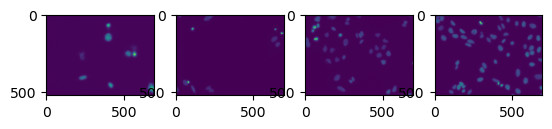

In [4]:
## Show a few images
fig, ax = plt.subplots(ncols = 4 )

ax[0].imshow(images[0])
ax[1].imshow(images[4])
ax[2].imshow(images[9])
ax[3].imshow(images[13])

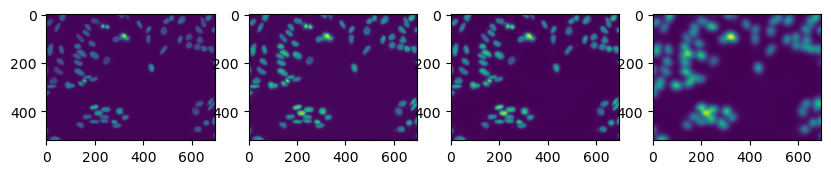

In [68]:
# local contrast
image = images[2]
img = skimage.exposure.equalize_adapthist(image, clip_limit = 0.01)
img_gauss_1 = scipy.ndimage.gaussian_filter(img, sigma = 0.5)
img_gauss_2 = scipy.ndimage.gaussian_filter(img, sigma = 2)
img_gauss_3 = scipy.ndimage.gaussian_filter(img, sigma = 10)

# plt.imshow(img)
fig, ax = plt.subplots(1, 4, figsize = (10, 20))
ax[0].imshow(image)
ax[1].imshow(img_gauss_1)
ax[2].imshow(img_gauss_2)
ax[3].imshow(img_gauss_3)

skimage.filters.thresholding.threshold_isodata
skimage.filters.thresholding.threshold_li
skimage.filters.thresholding.threshold_mean
skimage.filters.thresholding.threshold_minimum
skimage.filters.thresholding.threshold_otsu
skimage.filters.thresholding.threshold_triangle
skimage.filters.thresholding.threshold_yen


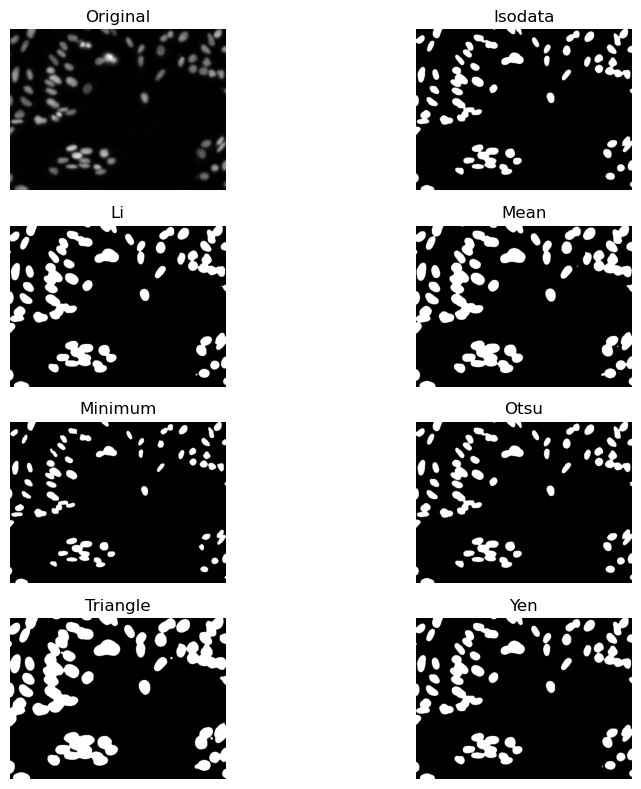

In [72]:
## img to use
img = img_gauss_2
fig, ax = skimage.filters.try_all_threshold(img, figsize=(10,8))
plt.show()

0.029810971117394454


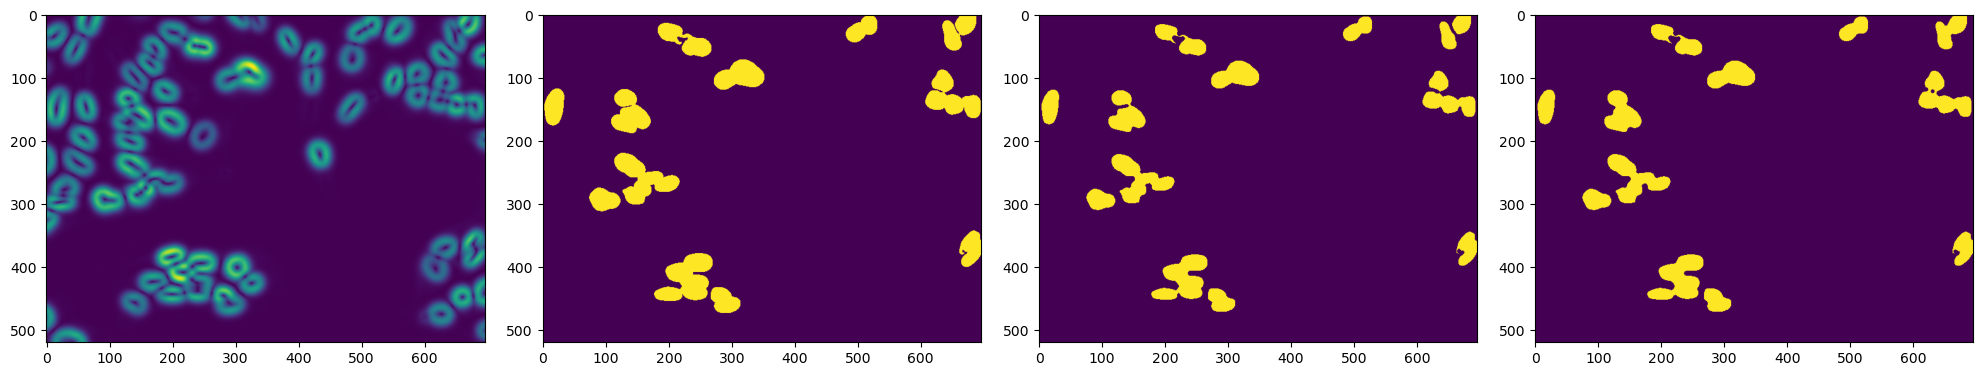

In [89]:


### background correction
from skimage.filters import sobel, gaussian, scharr

## find edges
edge = sobel(gaussian(img, sigma=5))
edge_sch = scharr(img)

edge_use = edge

### threshold and make mask
thresh = skimage.filters.threshold_otsu(edge_use)
print(thresh)
mask = edge_use > thresh
mask = skimage.morphology.remove_small_objects(mask, 1000)
mask = skimage.morphology.remove_small_holes(mask, 1000)
footprint = skimage.morphology.disk(2)
mask_erode = skimage.morphology.binary_erosion(mask, footprint)
mask_binary_close = skimage.morphology.binary_closing(mask_erode, skimage.morphology.disk(3))

plt.close('all')
fig, ax = plt.subplots(1,4, figsize=(20, 20))
fig.tight_layout()
ax[0].imshow(edge)
ax[1].imshow(mask)
ax[2].imshow(mask_erode)
ax[3].imshow(mask_binary_close)

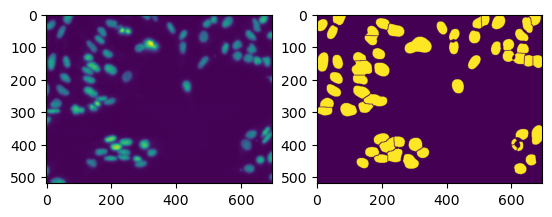

In [70]:
### already looks pretty good
## just need to split the three nuclei on the right
## try napari_segment_blobs_and_things_with_membranes  function split_touching_objects 
split_objects = nsbatwm.split_touching_objects(mask_binary_close) # sigma controls where to split. smaller sigma = more splits
## this looks pretty good
fig, ax = plt.subplots(1,2)
ax[0].imshow(img)
ax[1].imshow(split_objects)

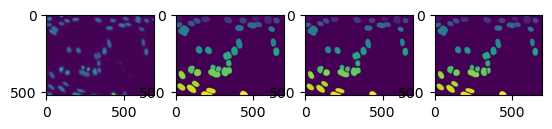

In [67]:
### label the different objects
## can label the objects before or after splitting them
## from Robert Haase's amazing napari plug ins
split_labels = nsitk.touching_objects_labeling(split_objects)
touching_labels = nsitk.touching_objects_labeling(mask_binary_close)
mask_labels = nsitk.touching_objects_labeling(mask)

fig, ax = plt.subplots(1,4)
ax[0].imshow(img)
ax[1].imshow(mask_labels)
ax[2].imshow(touching_labels)
ax[3].imshow(split_labels)

TypeError: ufunc 'invert' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

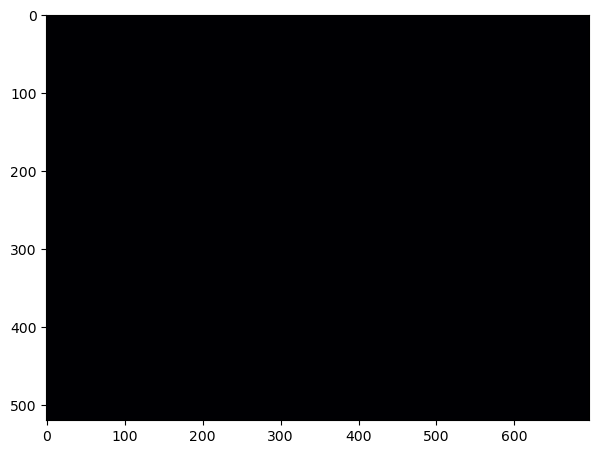

In [86]:
# (i) Label connected components

# Use the function 'ndi.label' from the 'ndimage' module. 
# Note that this function labels foreground pixels (1s, not 0s), so you may need 
# to invert your membrane mask just as for hole filling above.
# Also, note that 'ndi.label' returns another result in addition to the labeled 
# image. Read up on this in the function's documentation and make sure you don't
# mix up the two outputs!

cell_labels, _ = scipy.ndimage.label(img)

# Solution note: For functions with multiple outputs (here the labeled image on
# the one hand and the number of detected objects on the other), it is a python
# convention to unpack those outputs that will not be used in the remainder of 
# code into the variable '_' (underscore). This makes it clear to those reading
# the code that the function returns multiple things but some of them are not
# important in this case.
# (ii) Visualize the output

# Here, it is no longer ideal to use a 'gray' colormap, since we want to visualize that each
# cell has a unique ID. Play around with different colormaps (check the docs to see what
# types of colormaps are available) and choose one that you are happy with.

plt.figure(figsize=(7,7))
plt.imshow(cell_labels, interpolation='none', cmap='inferno')
plt.show()

[[False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]
 ...
 [False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]]


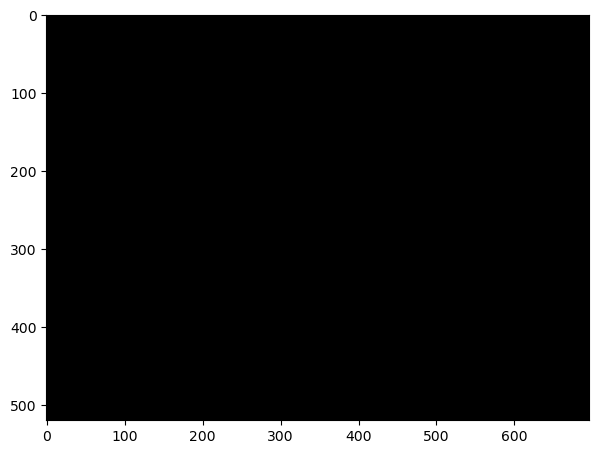

In [81]:

# Step 2
# ------

# (iv) Threshold the Gaussian-smoothed original image against the background image created in step 1 
#      using a relational expression

mem = img > bg


# (v) Visualize and understand the output. 

plt.figure(figsize=(7,7))
plt.imshow(mem, interpolation='none', cmap='gray')
plt.show()
